In [87]:
#starting the data cleaning process.
import pandas as pd
df=pd.read_csv("zomato.csv")
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [89]:
df.shape

(148, 7)

In [90]:
#to see whiich data is numeric 
df.dtypes

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object

In [91]:
#removing duplicates 
df.duplicated().sum()

np.int64(0)

In [92]:
#cleaning rate column
df["rate"]

0      4.1/5
1      4.1/5
2      3.8/5
3      3.7/5
4      3.8/5
       ...  
143    3.3/5
144    3.3/5
145    4.0/5
146    3.0/5
147    3.9/5
Name: rate, Length: 148, dtype: object

In [93]:
#handling invalid values.
#finding the unique values
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5'],
      dtype=object)

In [94]:
#removing /5
df['rate'] = df['rate'].str.replace('/5', '')
df['rate'].head

<bound method NDFrame.head of 0      4.1
1      4.1
2      3.8
3      3.7
4      3.8
      ... 
143    3.3
144    3.3
145    4.0
146    3.0
147    3.9
Name: rate, Length: 148, dtype: object>

In [95]:
#converting it into float
df['rate'] = df['rate'].astype(float)
df['rate']


0      4.1
1      4.1
2      3.8
3      3.7
4      3.8
      ... 
143    3.3
144    3.3
145    4.0
146    3.0
147    3.9
Name: rate, Length: 148, dtype: float64

In [96]:
df['rate'].dtype

dtype('float64')

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [98]:
df['online_order']#cleaning the online_order

0      Yes
1      Yes
2      Yes
3       No
4       No
      ... 
143     No
144     No
145    Yes
146     No
147    Yes
Name: online_order, Length: 148, dtype: object

In [99]:
df['online_order'] = df['online_order'].str.lower()
df['online_order'] = df['online_order'].map({'yes': 1, 'no': 0})
df['online_order']


0      1
1      1
2      1
3      0
4      0
      ..
143    0
144    0
145    1
146    0
147    1
Name: online_order, Length: 148, dtype: int64

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    int64  
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 8.2+ KB


In [101]:
#cleaning the book_table
df['book_table']

0      Yes
1       No
2       No
3       No
4       No
      ... 
143     No
144     No
145     No
146     No
147     No
Name: book_table, Length: 148, dtype: object

In [102]:
df['book_table'].unique()#checking the unique values.



array(['Yes', 'No'], dtype=object)

In [103]:
df['book_table'].value_counts()

book_table
No     140
Yes      8
Name: count, dtype: int64

In [104]:
df['book_table'].isnull().sum()

np.int64(0)

In [105]:
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})
df['book_table']

0      1
1      0
2      0
3      0
4      0
      ..
143    0
144    0
145    0
146    0
147    0
Name: book_table, Length: 148, dtype: int64

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    int64  
 2   book_table                   148 non-null    int64  
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 8.2+ KB


In [107]:
#cleaning listed_in 
df['listed_in(type)']


0      Buffet
1      Buffet
2      Buffet
3      Buffet
4      Buffet
        ...  
143    Dining
144    Dining
145    Dining
146    Dining
147    Dining
Name: listed_in(type), Length: 148, dtype: object

In [108]:
df['listed_in(type)'].unique()

array(['Buffet', 'Cafes', 'other', 'Dining'], dtype=object)

In [109]:
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

full eda process on the listed_in(type) [RESTAURANT CATEGORY]

<Axes: xlabel='listed_in(type)'>

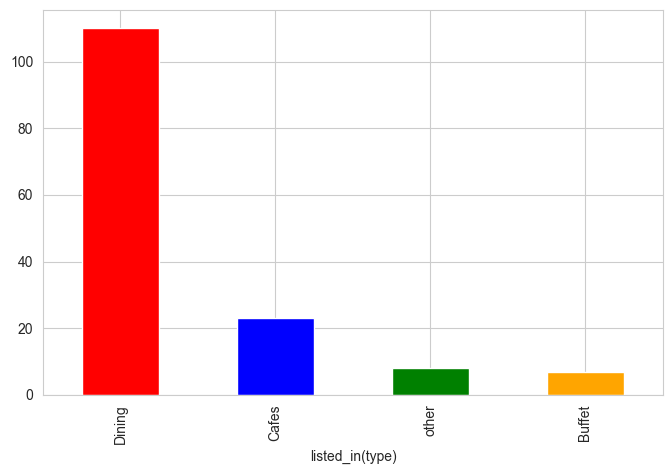

In [110]:
import matplotlib.pyplot as plt
df['listed_in(type)'].value_counts().plot(
    kind='bar',
    figsize=(8,5),
    color=['red','blue','green','orange']
)
#“The majority of restaurants belong to the dining category, followed by cafes, while buffet and other types are relatively less common.”

SHOWING LISTED_IN(TYPE) RESTAURANTS IN PIE CHARTS.

<Axes: ylabel='count'>

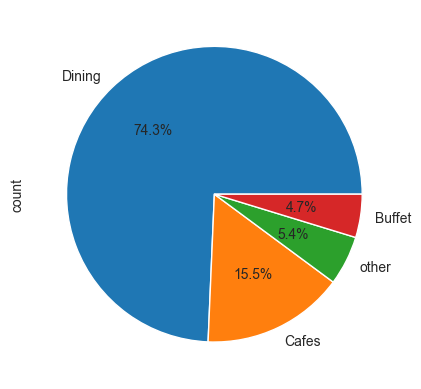

In [111]:
df['listed_in(type)'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

PIE CHARTS ONLINE ORDERS.

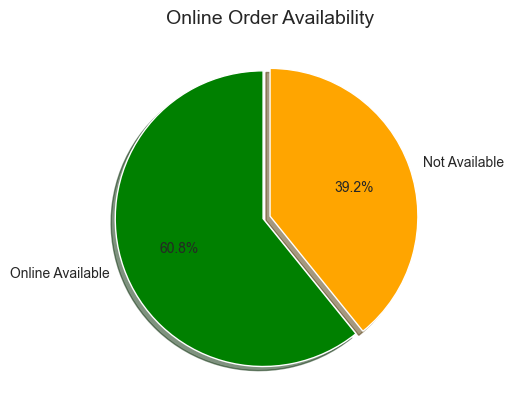

In [112]:
import matplotlib.pyplot as plt

df['online_order'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%', #WRITE PERCENTAGE ON THE CHART.
    labels=['Online Available','Not Available'],
    colors=['green','orange'],  # green & orange
    startangle=90, #ROTATE THE CHART FROM THE 90 DEGREE
    explode=(0.05, 0),   #HIGHLIGHTS THE SLICE [FIRST SLICE MOVES OUT.]
    shadow=True
)

plt.title("Online Order Availability", fontsize=14)
plt.ylabel("")
plt.show()

#“Approximately 60.8% of restaurants support online ordering, while 39.2% do not.”

#ONLINE RATINGS DISTRIBUTION 

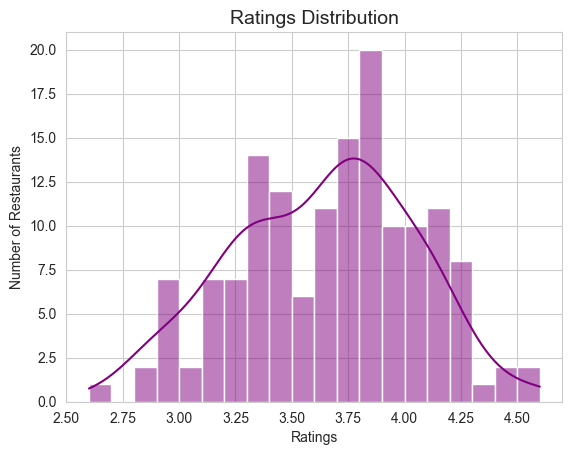

In [113]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.histplot(df['rate'], bins=20, kde=True, color='purple')

plt.title("Ratings Distribution", fontsize=14)
plt.xlabel("Ratings")
plt.ylabel("Number of Restaurants")

plt.show()
#“Most restaurants have ratings between 3.5 and 4.2.”

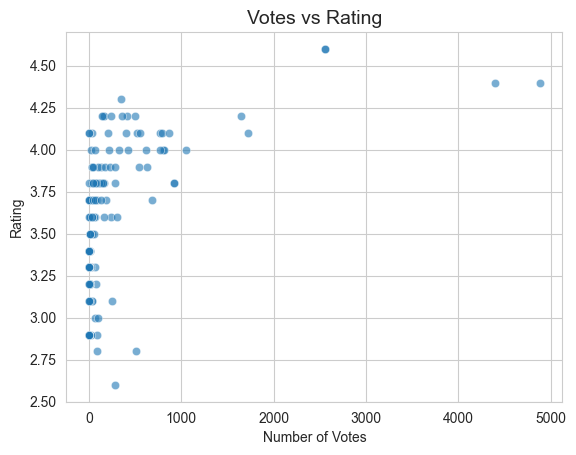

In [114]:
#making an comparison graph.
#VOTES VS RATINGS.

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

sns.scatterplot(
    x='votes',
    y='rate',
    data=df,
    alpha=0.6   # dots halka transparent
)

plt.title("Votes vs Rating", fontsize=14)
plt.xlabel("Number of Votes")
plt.ylabel("Rating")

plt.show()

#Restaurants with higher votes tend to have higher ratings, indicating that popular restaurants are generally well-rated

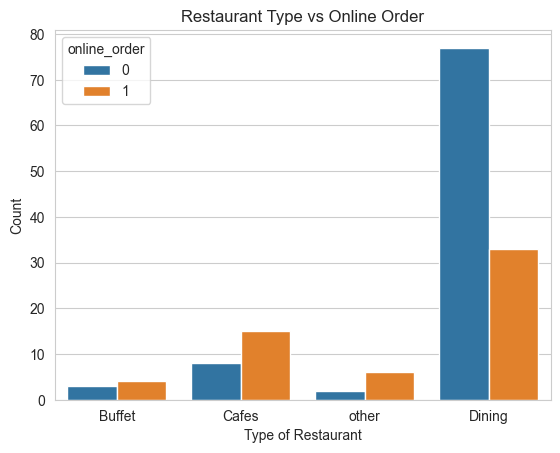

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='listed_in(type)',
    hue='online_order', #division of data through online_order is available or not.
    data=df
)

plt.title("Restaurant Type vs Online Order")
plt.xlabel("Type of Restaurant")
plt.ylabel("Count")

plt.show()

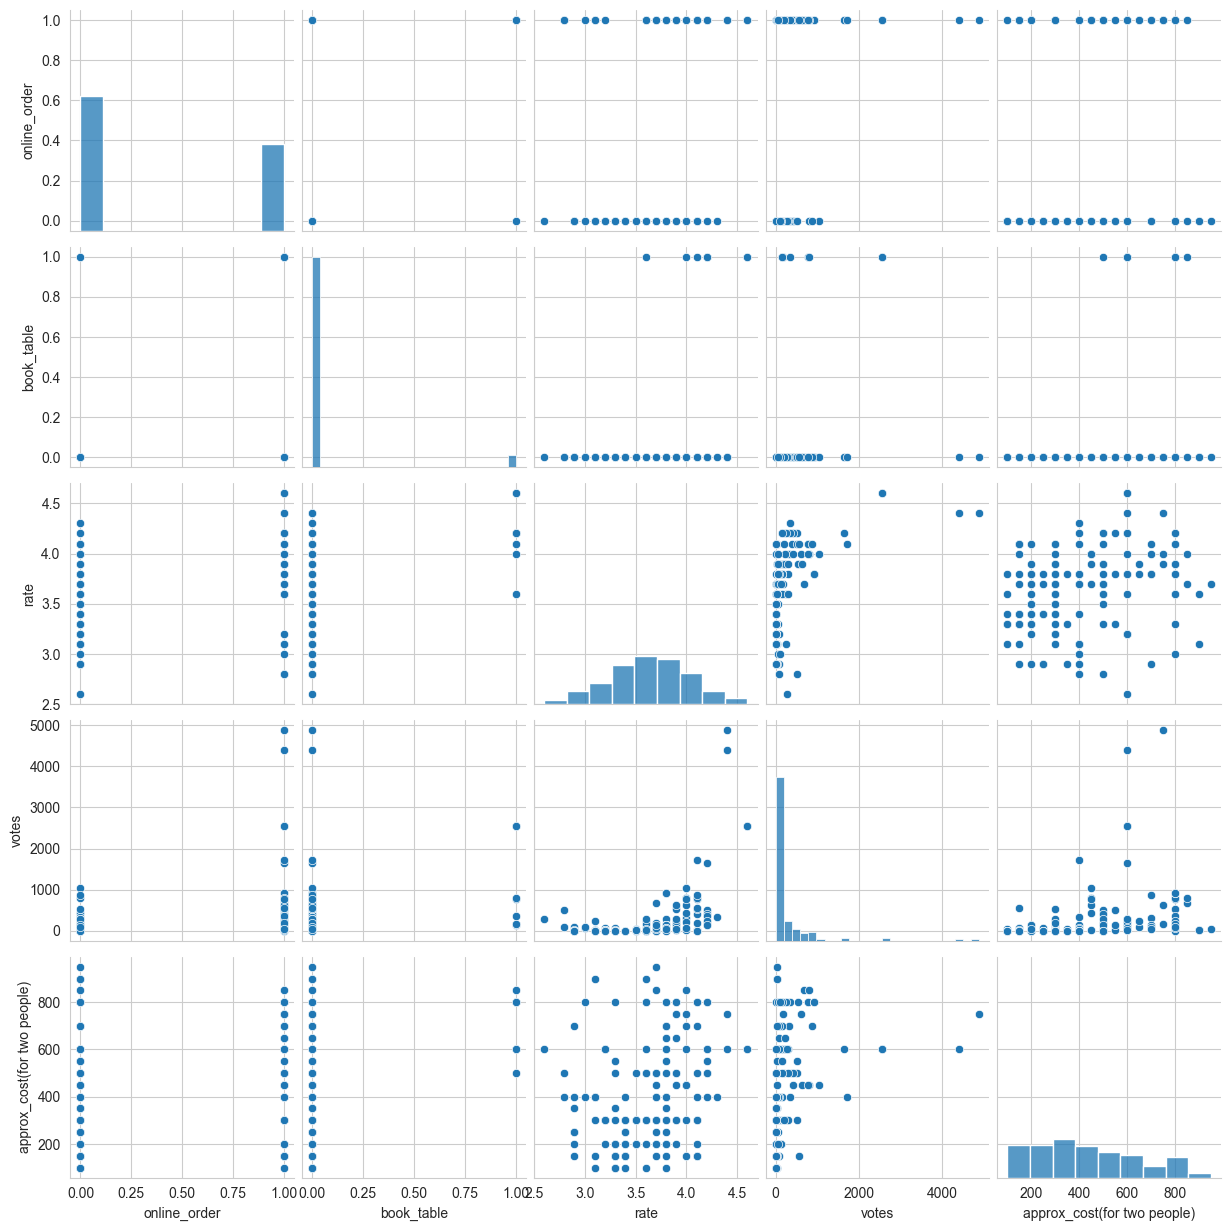

In [116]:
import seaborn as sns

sns.pairplot(df)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    int64  
 2   book_table                   148 non-null    int64  
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 8.2+ KB


In [118]:
df=df.drop(columns=["name"],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   online_order                 148 non-null    int64  
 1   book_table                   148 non-null    int64  
 2   rate                         148 non-null    float64
 3   votes                        148 non-null    int64  
 4   approx_cost(for two people)  148 non-null    int64  
 5   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(4), object(1)
memory usage: 7.1+ KB


In [119]:
df.head()

,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,1,1,4.1,775,800,Buffet
1,1,0,4.1,787,800,Buffet
2,1,0,3.8,918,800,Buffet
3,0,0,3.7,88,300,Buffet
4,0,0,3.8,166,600,Buffet


In [120]:
df["listed_in(type)"].unique()

array(['Buffet', 'Cafes', 'other', 'Dining'], dtype=object)

In [121]:
from sklearn.preprocessing import OneHotEncoder
cat_data=df[["listed_in(type)"]]
encoder=OneHotEncoder(sparse_output=False)#sparse=false[to become normal array]
encoded=encoder.fit_transform(cat_data)
encoded_columns=encoder.get_feature_names_out(["listed_in(type)"])
encoded_df=pd.DataFrame(encoded,columns=encoded_columns)
df=pd.concat([df,encoded_df],axis=1)
df

,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),listed_in(type)_Buffet,listed_in(type)_Cafes,listed_in(type)_Dining,listed_in(type)_other
0,1,1,4.1,775,800,Buffet,1.0,0.0,0.0,0.0
1,1,0,4.1,787,800,Buffet,1.0,0.0,0.0,0.0
2,1,0,3.8,918,800,Buffet,1.0,0.0,0.0,0.0
3,0,0,3.7,88,300,Buffet,1.0,0.0,0.0,0.0
4,0,0,3.8,166,600,Buffet,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
143,0,0,3.3,0,100,Dining,0.0,0.0,1.0,0.0
144,0,0,3.3,0,150,Dining,0.0,0.0,1.0,0.0
145,1,0,4.0,771,450,Dining,0.0,0.0,1.0,0.0
146,0,0,3.0,98,800,Dining,0.0,0.0,1.0,0.0


In [122]:
df = df.drop(columns=['listed_in(type)'])

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   online_order                 148 non-null    int64  
 1   book_table                   148 non-null    int64  
 2   rate                         148 non-null    float64
 3   votes                        148 non-null    int64  
 4   approx_cost(for two people)  148 non-null    int64  
 5   listed_in(type)_Buffet       148 non-null    float64
 6   listed_in(type)_Cafes        148 non-null    float64
 7   listed_in(type)_Dining       148 non-null    float64
 8   listed_in(type)_other        148 non-null    float64
dtypes: float64(5), int64(4)
memory usage: 10.5 KB


MAKING MACHINE LEARNING MODEL

In [131]:
#IDENTIFYING THE INDEENDENT AND DEPENDENT FEATURE.
X=df[["online_order","book_table","votes","approx_cost(for two people)","listed_in(type)_Buffet","listed_in(type)_Cafes","listed_in(type)_Dining","listed_in(type)_other"]]
y=df["rate"]


In [135]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)

In [133]:
X_train.shape
Y_train.shape

(37, 8)

In [136]:
#standardizing

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [139]:
#fitting it into regression model
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(X_train,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [140]:
#prediction
y_pred=regression.predict(X_test)
y_pred

array([3.48503023, 3.74557585, 3.48709405, 3.72477598, 3.48538272,
       3.97498468, 3.84211091, 3.94314791, 3.76500474, 3.81296921,
       3.73771982, 3.49792559, 3.48709405, 3.64065256, 3.48503023,
       3.74708147, 3.486791  , 3.74969305, 3.49123483, 3.76064609,
       3.49474496, 3.4882236 , 3.75498695, 3.48626852, 3.85220209,
       3.46999861, 3.5013011 , 3.48750682, 3.48923127, 3.97160917,
       3.48709405, 3.49158732, 3.48636682, 3.46892934, 3.58786553,
       3.48896395, 3.48709405])

In [141]:
#checking some important metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error

print("MAE:", mean_absolute_error(Y_test, y_pred))
print("MSE:", mean_squared_error(Y_test, y_pred))



MAE: 0.3222062409631881
MSE: 0.16197474883333268


In [143]:
import pickle

pickle.dump(regression, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))